In [ ]:
# ==========================
# 1️⃣ Mount Google Drive
# ==========================
from google.colab import drive
drive.mount('/content/drive')

# Path to your project folder in Drive
project_path = "/content/drive/MyDrive/Nutrilens_project/"
zip_file = "Khana_Split.zip"

# Full path to zip
zip_path = project_path + zip_file

# ==========================
# 2️⃣ Check if zip exists
# ==========================
import os
if not os.path.exists(zip_path):
    raise FileNotFoundError(f"{zip_path} not found in Drive!")
else:
    print(f"✅ Found zip file: {zip_path}")

# ==========================
# 3️⃣ Inspect zip structure (first 20 lines)
# ==========================
!unzip -l "{zip_path}" | head -20

# ==========================
# 4️⃣ Unzip properly
# ==========================
# Decide extraction path
extract_path = "/content/Khana_Split"

# Remove any leftover broken folders (optional)
!rm -rf "{extract_path}"

# Unzip quietly and overwrite if needed
!unzip -o -q "{zip_path}" -d "/content/"

# Rename if internal zip added extra top-level folder
if os.path.exists("/content/Khana_Split/Khana_Split"):
    os.rename("/content/Khana_Split/Khana_Split", "/content/Khana_Split")

print("✅ Unzip complete.")

# ==========================
# 5️⃣ Verify folder structure and image counts
# ==========================
base_dir = extract_path

print("\nTop-level folders:", os.listdir(base_dir))

# Check images per split and class
for split in ['train', 'val', 'test']:
    split_dir = os.path.join(base_dir, split)
    if os.path.exists(split_dir):
        print(f"\n{split} images per class:")
        for cls in os.listdir(split_dir):
            cls_dir = os.path.join(split_dir, cls)
            num_imgs = len([f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"{cls}: {num_imgs}")
    else:
        print(f"⚠️ {split} folder not found!")


Mounted at /content/drive
✅ Found zip file: /content/drive/MyDrive/Nutrilens_project/Khana_Split.zip
Archive:  /content/drive/MyDrive/Nutrilens_project/Khana_Split.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2025-10-19 05:59   Khana_Split/
        0  2025-10-19 06:03   Khana_Split/test/
        0  2025-10-19 06:00   Khana_Split/test/aloo gobi/
    41853  2025-10-19 06:00   Khana_Split/test/aloo gobi/05d6c4af07372e8d397015ab3055f455.jpg
    32703  2025-10-19 06:00   Khana_Split/test/aloo gobi/156bf66499ee324d8ef23de2928673dc.jpg
    42032  2025-10-19 06:00   Khana_Split/test/aloo gobi/15bba74a99dd7d9c8602f640c96cdc14.jpg
    59996  2025-10-19 06:00   Khana_Split/test/aloo gobi/163b1cfd2526988986e097a6e9d567f8.jpg
    46335  2025-10-19 06:00   Khana_Split/test/aloo gobi/1748967c5bd915b8be8239204fc80996.jpg
    38841  2025-10-19 06:00   Khana_Split/test/aloo gobi/2e28a0da05826964fef7fde76673f282.jpg
    23260  2025-10-19 06:00   Khana_Split/test/al

In [ ]:
!pip install tensorflow keras matplotlib


In [ ]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input


In [ ]:
# Paths
base_dir = "/content/Khana_Split"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & test generator (no augmentation)
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 60998 images belonging to 32 classes.
Found 7613 images belonging to 32 classes.
Found 7652 images belonging to 32 classes.


In [ ]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base layers
base_model.trainable = False

# Add custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,385,731 (16.73 MB)

 Trainable params: 336,160 (1.28 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10  # start with 10, can increase
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 911s 463ms/step - accuracy: 0.4852 - loss: 1.9593 - val_accuracy: 0.7996 - val_loss: 0.6941
Epoch 2/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 789s 414ms/step - accuracy: 0.7606 - loss: 0.8230 - val_accuracy: 0.8291 - val_loss: 0.5765
Epoch 3/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 780s 409ms/step - accuracy: 0.7801 - loss: 0.7341 - val_accuracy: 0.8405 - val_loss: 0.5406
Epoch 4/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 784s 411ms/step - accuracy: 0.7988 - loss: 0.6708 - val_accuracy: 0.8466 - val_loss: 0.5109
Epoch 5/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 779s 409ms/step - accuracy: 0.8023 - loss: 0.6557 - val_accuracy: 0.8539 - val_loss: 0.4900
Epoch 6/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 791s 414ms/step - accuracy: 0.8081 - loss: 0.6370 - val_accuracy: 0.8554 - val_loss: 0.4804
Epoch 7/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 790s 414ms/step - accuracy: 0.8115 - loss: 0.6246 - val_accuracy: 0.8580 - val_loss: 0.4796
Epoch 8/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 792s 415ms/step - ac

In [ ]:
# Unfreeze last few layers of EfficientNetB0
for layer in base_model.layers[-50:]:
    layer.trainable = True

# Recompile with lower LR
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Continue training
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 853s 431ms/step - accuracy: 0.6939 - loss: 1.0873 - val_accuracy: 0.8567 - val_loss: 0.4921
Epoch 2/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 791s 415ms/step - accuracy: 0.8091 - loss: 0.6440 - val_accuracy: 0.8721 - val_loss: 0.4325
Epoch 3/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 794s 416ms/step - accuracy: 0.8292 - loss: 0.5623 - val_accuracy: 0.8815 - val_loss: 0.4007
Epoch 4/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 800s 420ms/step - accuracy: 0.8457 - loss: 0.5121 - val_accuracy: 0.8877 - val_loss: 0.3807
Epoch 5/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 810s 425ms/step - accuracy: 0.8538 - loss: 0.4823 - val_accuracy: 0.8918 - val_loss: 0.3628
Epoch 6/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 800s 419ms/step - accuracy: 0.8659 - loss: 0.4493 - val_accuracy: 0.8958 - val_loss: 0.3519
Epoch 7/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 794s 416ms/step - accuracy: 0.8665 - loss: 0.4423 - val_accuracy: 0.8999 - val_loss: 0.3397
Epoch 8/10
1907/1907 ━━━━━━━━━━━━━━━━━━━━ 798s 419ms/step - ac

In [ ]:
# Evaluate on test data
test_loss, test_acc = model.evaluate(test_generator)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")
print(f"🧾 Test Loss: {test_loss:.4f}")


240/240 ━━━━━━━━━━━━━━━━━━━━ 31s 127ms/step - accuracy: 0.8899 - loss: 0.3650
✅ Test Accuracy: 90.87%
🧾 Test Loss: 0.3134


240/240 ━━━━━━━━━━━━━━━━━━━━ 32s 104ms/step
📊 Classification Report:
                  precision    recall  f1-score   support

       aloo gobi       0.73      0.66      0.69       102
    aloo paratha       0.95      0.95      0.95       316
      anda curry       0.88      0.84      0.86       326
   bhindi masala       0.86      0.79      0.82        61
         biryani       0.87      0.94      0.90       665
    chana masala       0.82      0.84      0.83       288
         chapati       0.90      0.91      0.91       225
   chicken wings       0.92      0.93      0.92       255
   chole bhature       0.91      0.97      0.93       119
     dal khichdi       0.90      0.89      0.89       126
          dhokla       0.88      0.82      0.85       122
      fish curry       0.68      0.67      0.68       156
     gulab jamun       0.98      0.99      0.99       297
hara bhara kabab       0.94      0.99      0.96       163
            idli       0.93      0.89      0.91       584
  

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127857 (\N{BENTO BOX}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


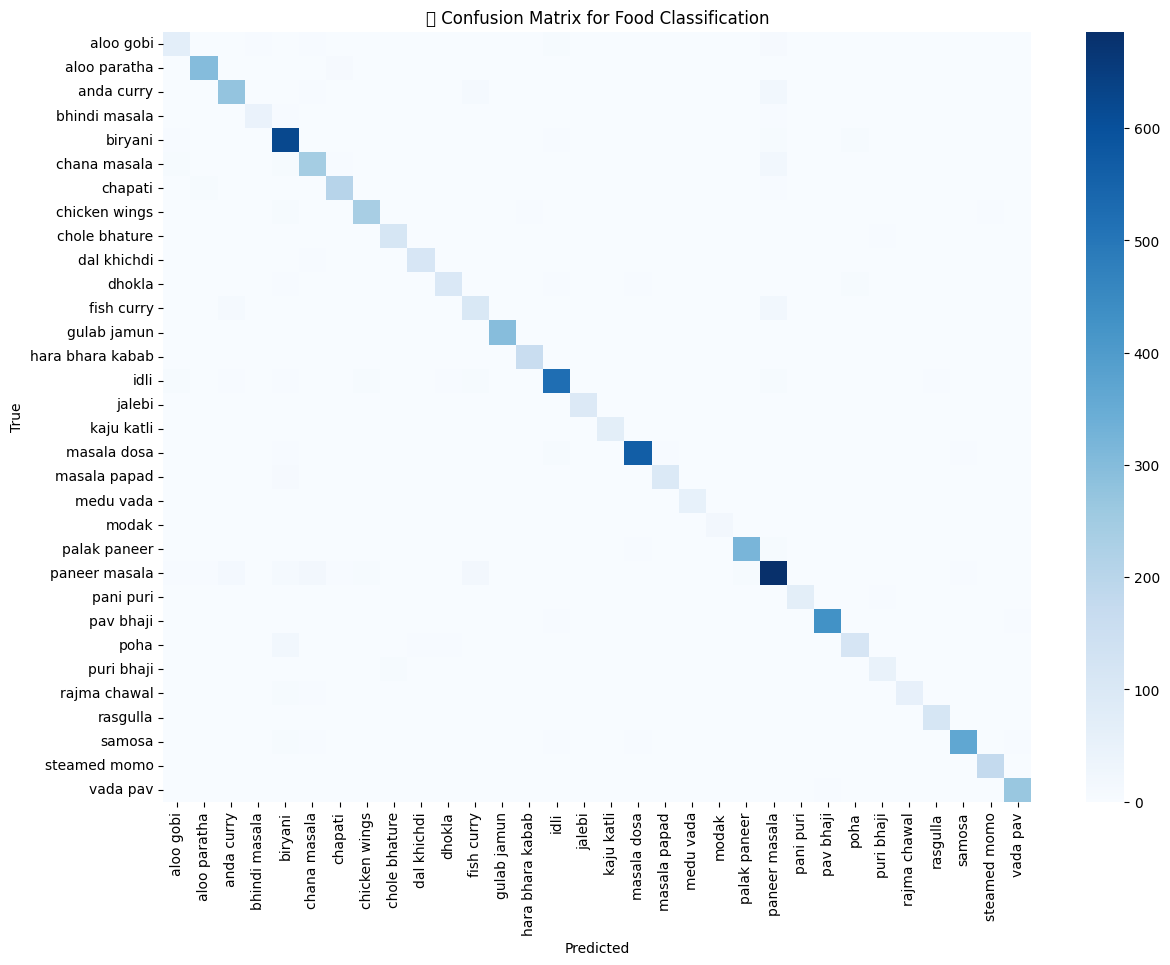

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get true and predicted labels
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Print classification report
print("📊 Classification Report:")
print(classification_report(test_generator.classes, y_pred, target_names=test_generator.class_indices.keys()))

# Confusion matrix
cm = confusion_matrix(test_generator.classes, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.title('🍱 Confusion Matrix for Food Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


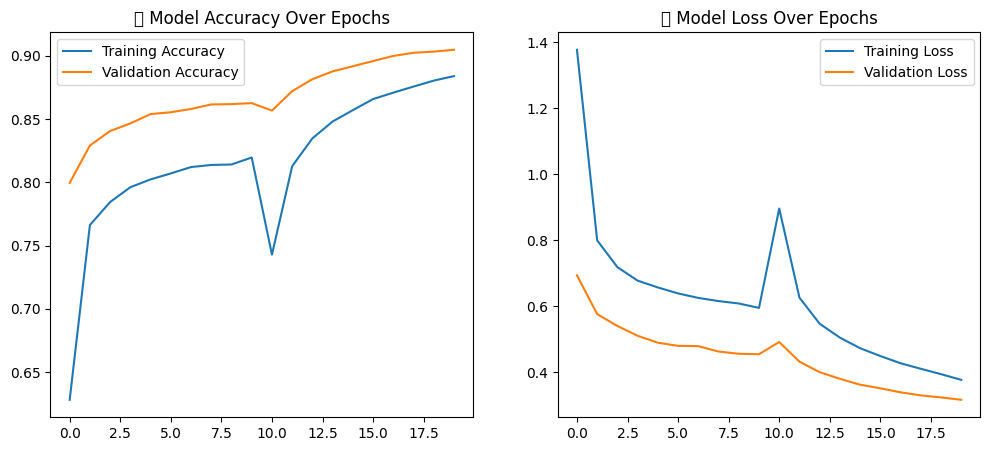

In [ ]:
# Plot accuracy and loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'] + history_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'] + history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('📈 Model Accuracy Over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'] + history_finetune.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'] + history_finetune.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('📉 Model Loss Over Epochs')

plt.show()


In [ ]:
# ✅ Save model in new recommended Keras format
model.save('/content/drive/MyDrive/Nutrilens_project/efficientnet_food_model.keras')

# ✅ (Optional) Also save in legacy .h5 format for compatibility
model.save('/content/drive/MyDrive/Nutrilens_project/efficientnet_food_model.h5')

print("✅ Model saved successfully in both .keras and .h5 formats!")



✅ Model saved successfully in both .keras and .h5 formats!


In [ ]:
# ✅ Export for deployment (TensorFlow SavedModel format)
model.export('/content/drive/MyDrive/Nutrilens_project/efficientnet_food_model_export')


Saved artifact at '/content/drive/MyDrive/Nutrilens_project/efficientnet_food_model_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 32), dtype=tf.float32, name=None)
Captures:
  140306248630928: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  140306248630736: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  140306279253968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140306279253776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140306279253008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140306294274960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140306279255120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140306279255312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140306279257040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1403062792